# Acoustic Feature Extraction from African Elephant Rumbles

DATASET

Collar-borne AudioMoth recordings from Arden deployed in June 2025 within Samburu National Reserve, Kenya

GOALS

1) Extract acoustic features from rumble vocalizations that are relevant to rumble detection/classification.
   1) Can look at Pardo et al. 2024 to see how they did feature extraction: https://doi.org/10.1098/rsos.241264. There is open source code from this publication here: https://datadryad.org/dataset/doi:10.5061/dryad.rv15dv4dt/.
   2) Determine if calls with 'quality' label of 2 are sufficient for data upload
3) Plot a histogram for each extracted feature
4) Test which extracted features best identify rumbles from background noise by comparing with randomly extracted clips of similar duration
5) Cross correlation to identify and remove correlated features

## Import and Directories

In [1]:
# import libraries

import pandas as pd
import numpy as np
import librosa
import soundfile as sf
from pathlib import Path
from datetime import datetime, timedelta
import os
from scipy.signal import butter, sosfilt
import matplotlib.pyplot as plt

In [2]:
# define directories

# annotation directory containing Raven annotation files
annotation_dir = Path(os.getenv('ANNOTATION_PATH'))

# audio directory containing wav files corresponding with annotation files
audio_dir = Path(os.getenv('AUDIO_PATH'))

# list just the first five annotation files as a check
ann_files = sorted(annotation_dir.glob("*.txt"))
print(f"Found {len(ann_files)} annotation files")
for f in ann_files[:5]:
    print(f.name)

Found 61 annotation files
Arden_20250606_130050.txt
Arden_20250606_140055.txt
Arden_20250606_150100.txt
Arden_20250606_160105.txt
Arden_20250606_170110.txt


## Initial Testing (with single clip)

In [3]:
# load annotation file to experiment with

ann_path = ann_files[0]

df = pd.read_csv(ann_path, sep='\t')
print(df.shape)
df.head()

(51, 11)


,Selection,View,Channel,Begin Time (s),End Time (s),Low Freq (Hz),High Freq (Hz),call_type,quality,overlap,earflap
0,1,Spectrogram 1,1,437.097736,440.996251,0.0,913.0,ROAR,2,N,0
1,3,Spectrogram 1,1,444.801943,450.649715,0.0,918.9,ROAR,2,N,o
2,4,Spectrogram 1,1,464.619390,470.833604,0.0,232.7,RUM,3,N,1
3,5,Spectrogram 1,1,474.246619,479.858403,0.0,249.1,RUM,3,N,0
4,6,Spectrogram 1,1,492.975502,498.869685,0.0,216.3,RUM,3,N,1


In [4]:
# create a function to extract timestamp from filename

def parse_recording_start(filename):
    stem = Path(filename).stem
    parts = stem.split('_')
    date_str = parts[-2]
    time_str = parts[-1]
    return datetime.strptime(date_str + time_str, '%Y%m%d%H%M%S')

# and test
rec_start = parse_recording_start(ann_path)
print(rec_start)

# this should print the timestamp of the first file

2025-06-06 13:00:50


In [5]:
# load the matching wav file

filename = Path(ann_path.stem + ".wav")
wav_path = audio_dir / filename
print(wav_path)

audio, sr = librosa.load(wav_path, sr=None)
print(f"Sample rate: {sr} Hz")

/Volumes/Extreme SSD/a3em/audio-datasets/elephantsSamburu2025/audiomoth/Arden_20250606_130050.wav
Sample rate: 4000 Hz


In [6]:
# test extract a clip from this wav file

BUFFER = 0.2 # seconds to add to either side of vocalization

# test first row that is a rumble (2)
row = df.iloc[2]

# convert times to sample indices
start_sample = int((row['Begin Time (s)'] - BUFFER) * sr)
end_sample = int((row['End Time (s)'] + BUFFER) * sr)

clip = audio[start_sample:end_sample]

#print duration and type
print(f"clip duration {len(clip)/sr} secs")
print(f"Call Type {row['call_type']}")

clip duration 6.61425 secs
Call Type RUM


In [7]:
# preprocessing function
# not sure the best values for the bandpass filter to implement?
# trying to follow similar strategy as Pardo et al 2025 (filtering details in supplemental info): https://pmc.ncbi.nlm.nih.gov/articles/PMC11421903/

def preprocess(clip,sr):
    # high pass filter
    high_pass = butter(2, 15, btype='highpass', fs=sr, output='sos')
    clip = sosfilt(high_pass, clip)

    # low pass filter
    low_pass = butter(2, 200, btype='lowpass', fs=sr, output='sos')
    clip = sosfilt(low_pass, clip)

    # normalize 70%
    clip = clip / np.max(np.abs(clip)) * 0.7

    return clip

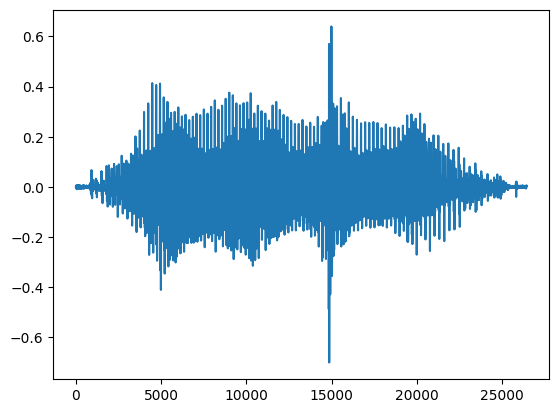

In [8]:
# test preprocessing function (plot a rumble clip)

clip_processed = preprocess(clip,sr)
plt.plot(clip_processed)

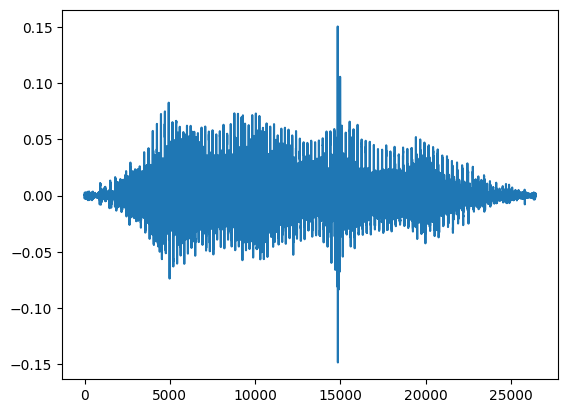

In [9]:
# compare with original clip (before processing)

plt.plot(clip)

In [10]:
# Feature Extraction
# probabyl going to add features here, open to suggestions

# compute power spectrogram
S = np.abs(librosa.stft(clip_processed))**2
power_per_freq = S.mean(axis=1)

# thinking mel spectrogram is better
S_mel = librosa.feature.melspectrogram(y=clip_processed, sr=sr, n_mels=26)

# freq values (for each row S)
freqs  = librosa.fft_frequencies(sr=sr)

# Peak frequency
peak_freq = freqs[np.argmax(S.mean(axis=1))]

# centroid
centroid = librosa.feature.spectral_centroid(y=clip_processed, sr=sr)
mean_centroid = centroid.mean()

# bandwidth
bandwidth = librosa.feature.spectral_bandwidth(y=clip_processed, sr=sr)
mean_bandwidth = bandwidth.mean()

# 5% and 95% frequency bounds
power_per_freq = S.mean(axis=1)
cumulative = np.cumsum(power_per_freq)
cumulative = cumulative /cumulative[-1]
freq_5 = freqs[np.searchsorted(cumulative, 0.05)]
freq_95 = freqs[np.searchsorted(cumulative, 0.95)]

#duration
duration = row['End Time (s)'] - row['Begin Time (s)']

print(f"Duration: {duration}")
print(f"Peak freq: {peak_freq}")
print(f"Centroid: {mean_centroid}")
print(f"Bandwidth: {mean_bandwidth}")
print(f"Freq 5: {freq_5}")
print(f"Freq 95: {freq_95}")

Duration: 6.214213868999991
Peak freq: 37.109375
Centroid: 122.84113282511007
Bandwidth: 133.61833587195068
Freq 5: 31.25
Freq 95: 126.953125


In [52]:
import matplotlib.colors as mcolors

# function for visualizing the different audio features.
def visualize_clip(clip_processed, features, n_fft=1024):
    spec_proc = librosa.amplitude_to_db(np.abs(librosa.stft(clip_processed, n_fft=n_fft, hop_length=128)), ref=np.max)
    fig, ax = plt.subplots()
    _ = librosa.display.specshow(spec_proc, sr=sr, hop_length=128, x_axis='time', y_axis='hz', ax=ax)
    plt.ylim(0,200)

    colors = list(mcolors.BASE_COLORS)
    for feature, value in features.items():
        if feature != 'duration' and feature != 'bandwidth':
            ax.axhline(value, color=colors.pop(), linestyle='-.', label=f'{feature} {value}')
    ax.legend(fontsize=8)

    return fig

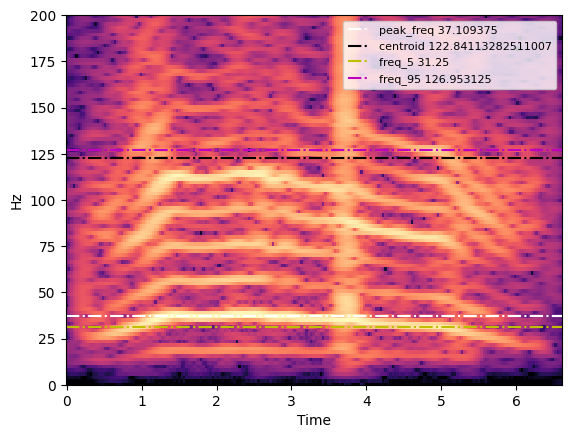

In [53]:
features = {
    'peak_freq': peak_freq,
    'centroid': mean_centroid,
    'bandwidth': mean_bandwidth,
    'duration': duration,
    'freq_5': freq_5,
    'freq_95': freq_95,
}

fig = visualize_clip(clip_processed, features, 2048)

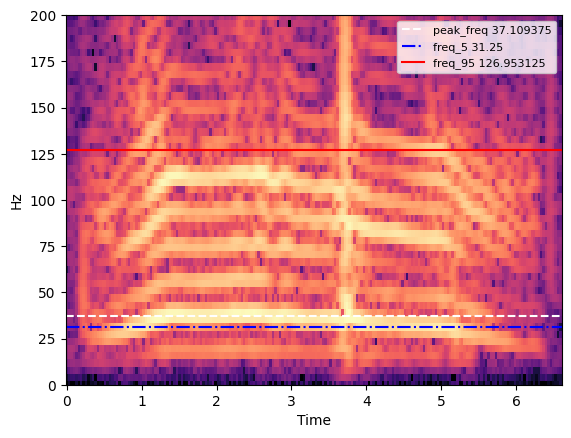

In [11]:
# plot spectrogram of processed clip
# also include

spec_proc = librosa.amplitude_to_db(np.abs(librosa.stft(clip_processed, n_fft=1024, hop_length=128)), ref=np.max)
fig, ax = plt.subplots()
img_proc = librosa.display.specshow(spec_proc, sr=sr, hop_length=128, x_axis='time', y_axis='hz', ax=ax)
plt.ylim(0,200)

ax.axhline(peak_freq,color='white',linestyle='--',label=f'peak_freq {peak_freq}')
ax.axhline(freq_5,color='blue',linestyle='-.',label=f'freq_5 {freq_5}')
ax.axhline(freq_95,color='red',linestyle='-',label=f'freq_95 {freq_95}')
ax.legend(fontsize=8)


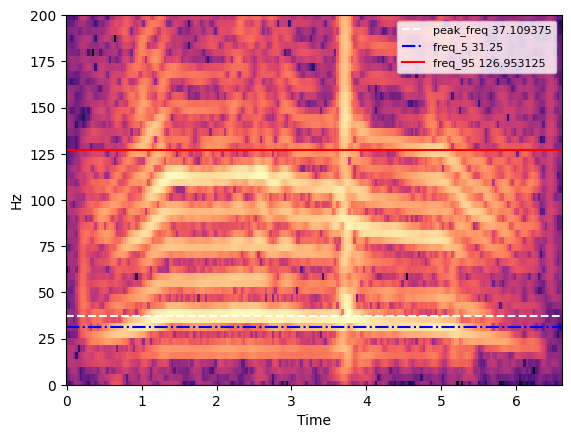

In [12]:
# compare with original (without preprocessing)

spec_orig = librosa.amplitude_to_db(np.abs(librosa.stft(clip, n_fft=1024, hop_length=128)), ref=np.max)
fig, ax = plt.subplots()
img_orig = librosa.display.specshow(spec_orig, sr=sr, hop_length=128, x_axis='time', y_axis='hz', ax=ax)
plt.ylim(0,200)

ax.axhline(peak_freq,color='white',linestyle='--',label=f'peak_freq {peak_freq}')
ax.axhline(freq_5,color='blue',linestyle='-.',label=f'freq_5 {freq_5}')
ax.axhline(freq_95,color='red',linestyle='-',label=f'freq_95 {freq_95}')
ax.legend(fontsize=8)

## Automate Extraction (for all clips)

In [ ]:
# make a function for feature extraction

def feature_extract(clip,sr):
    
    # spectrograms
    S = np.abs(librosa.stft(clip))**2
    power_per_freq = S.mean(axis=1)
    S_mel = librosa.feature.melspectrogram(y=clip, sr=sr, n_mels=26)

    #peak freq
    freqs  = librosa.fft_frequencies(sr=sr)
    freq_mask = (freqs > 15) & (freqs < 60)
    peak_freq = freqs[freq_mask][np.argmax(power_per_freq[freq_mask])]

    #centroid
    centroid = librosa.feature.spectral_centroid(y=clip, sr=sr)
    mean_centroid = centroid.mean()

    # bandwidth
    bandwidth = librosa.feature.spectral_bandwidth(y=clip, sr=sr)
    mean_bandwidth = bandwidth.mean()

    # 5% and 95% freqs
    cumulative = np.cumsum(power_per_freq)
    cumulative = cumulative /cumulative[-1]
    freq_5 = freqs[np.searchsorted(cumulative, 0.05)]
    freq_95 = freqs[np.searchsorted(cumulative, 0.95)]

    # MFCCS
    mfccs = librosa.feature.mfcc(y=clip, sr=sr, n_mfcc=13)
    mfcc_dict = {f'mfcc_{i+1}': mfccs[i].mean() for i in range(13)}

    mel_means = S_mel.mean(axis=1)
    mel_dict = {f'mel_mean_{i+1}': v for i, v in enumerate(mel_means)}

    # ADD
    # spectral flatness

    return {
        'peak_freq': peak_freq,
        'centroid': mean_centroid,
        'bandwidth': mean_bandwidth,
        'duration': duration,
        'freq_5': freq_5,
        'freq_95': freq_95,
        **mfcc_dict,
        **mel_dict
    }
    
print(feature_extract(clip,sr))

{'peak_freq': 37.109375, 'centroid': 541.2680565699619, 'bandwidth': 571.9253497438707, 'duration': 6.214213868999991, 'freq_5': 31.25, 'freq_95': 310.546875, 'mfcc_1': -270.53983, 'mfcc_2': 53.391605, 'mfcc_3': 31.043531, 'mfcc_4': 22.57233, 'mfcc_5': 13.948421, 'mfcc_6': 8.823491, 'mfcc_7': 16.105408, 'mfcc_8': 19.417015, 'mfcc_9': 17.124386, 'mfcc_10': 0.60912454, 'mfcc_11': 4.3508673, 'mfcc_12': -3.4541674, 'mfcc_13': -6.443453, 'mel_mean_1': 1.9048041, 'mel_mean_2': 1.1701791, 'mel_mean_3': 0.10025417, 'mel_mean_4': 0.01702672, 'mel_mean_5': 0.015763177, 'mel_mean_6': 0.028620021, 'mel_mean_7': 0.033286214, 'mel_mean_8': 0.030321943, 'mel_mean_9': 0.015534194, 'mel_mean_10': 0.0045291674, 'mel_mean_11': 0.0057698954, 'mel_mean_12': 0.004346172, 'mel_mean_13': 0.004776872, 'mel_mean_14': 0.0053100158, 'mel_mean_15': 0.009400818, 'mel_mean_16': 0.008460027, 'mel_mean_17': 0.0039311247, 'mel_mean_18': 0.0033221168, 'mel_mean_19': 0.0033882314, 'mel_mean_20': 0.004063705, 'mel_mean_21

In [14]:
# filter out high quality rumbles
# this means only rumbles, no overlapping, identified as high quality, and no ear flapping

df = pd.read_csv(ann_files[0], sep='\t')
print(f"Total detections before filter: {len(df)}")

df['earflap'] = pd.to_numeric(df['earflap'], errors='coerce')

df_filtered = df[
    (df['call_type'] == 'RUM') &
    (df['earflap'].isin([0])) &
    (df['quality'].isin([3, 4])) &
    (df['overlap']  == 'N')
]

print(f"Total detections after filter: {len(df_filtered)}")
df_filtered

Total detections before filter: 51
Total detections after filter: 2


,Selection,View,Channel,Begin Time (s),End Time (s),Low Freq (Hz),High Freq (Hz),call_type,quality,overlap,earflap
3,5,Spectrogram 1,1,474.246619,479.858403,0.0,249.1,RUM,3,N,0.0
8,10,Spectrogram 1,1,579.161466,586.030277,0.0,186.5,RUM,3,N,0.0


In [28]:
# loop over all files and all high quality detections
# high quality defined as (1) rumble, (2) no ear flapping noise, (3) quality of 2 or higher, and (4) not overlapping

# incorporate all extracted feature information for each vocalization
# incorporate all original annotation labels

all_rows = []

for ann_path in ann_files:

    # only include high quality rumbles
    df = pd.read_csv(ann_path, sep='\t')
    df['earflap'] = pd.to_numeric(df['earflap'], errors='coerce')
    df = df[
        (df['call_type'] == 'RUM') &
        (df['earflap'].isin([0])) &
        (df['quality'].isin([3, 4])) &
        (df['overlap']  == 'N')
    ]

    # parse recording start time from filename
    parts = ann_path.stem.split('_')
    rec_start = datetime.strptime(parts[1] + parts[2], '%Y%m%d%H%M%S')

    # load matching audio
    wav_path = audio_dir / (ann_path.stem + '.wav')
    audio, sr = librosa.load(wav_path, sr=2000)

    # loop over each detection in file
    for i in range(len(df)):
        row = df.iloc[i]

        # extract
        start_sample = int((row['Begin Time (s)'] - BUFFER) * sr)
        end_sample = int((row['End Time (s)'] + BUFFER) * sr)

        start_time = rec_start + timedelta(seconds = row['Begin Time (s)'])
        start_time.strftime('%Y%m%d_%H%M%S')
        
        clip = audio[start_sample:end_sample]

        clip_processed = preprocess(clip,sr)

        # extract features"
        features = feature_extract(clip_processed, sr)

        # combine original annotation info
        combined = {
            'filename': ann_path.stem,
            'rec_start': rec_start,
            'abs_begin': rec_start + timedelta(seconds=row['Begin Time (s)']),
            'abs_end': rec_start + timedelta(seconds=row['End Time (s)']),
            'duration': row['End Time (s)'] - row['Begin Time (s)'],
            **row.to_dict(),
            **features,
        }
        
        all_rows.append(combined)

        # save spectrogram image with summary stats for review
            
        spec_proc = librosa.amplitude_to_db(np.abs(librosa.stft(clip_processed, n_fft=1024, hop_length=128)), ref=np.max)
        fig, ax = plt.subplots()
        img_proc = librosa.display.specshow(spec_proc, sr=sr, hop_length=128, x_axis='time', y_axis='hz', ax=ax)
        plt.ylim(0,200)

        peak_freq = features['peak_freq']
        freq_5 = features['freq_5']
        freq_95 = features['freq_95']
        
        ax.axhline(features['peak_freq'],color='white',linestyle='--',label=f'peak_freq {peak_freq}')
        ax.axhline(features['freq_5'],color='blue',linestyle='-.',label=f'freq_5 {freq_5}')
        ax.axhline(features['freq_95'],color='red',linestyle='-',label=f'freq_95 {freq_95}')
        ax.legend(fontsize=8, loc='upper right')

        # make sure the path exists
        fig_path = os.getenv('FIG_PATH')
        st = start_time.strftime('%Y%m%d_%H%M%S')
        fig.savefig(os.path.join(fig_path, f'{start_time}_spectrogram.png'), dpi=150,bbox_inches='tight')

        plt.close(fig)
        

In [29]:
# print how many clips

print(f"Total rows collected: {len(all_rows)}")
results = pd.DataFrame(all_rows)
results.head()

Total rows collected: 184


,filename,rec_start,abs_begin,abs_end,duration,Selection,View,Channel,Begin Time (s),End Time (s),...,mel_mean_17,mel_mean_18,mel_mean_19,mel_mean_20,mel_mean_21,mel_mean_22,mel_mean_23,mel_mean_24,mel_mean_25,mel_mean_26
0,Arden_20250606_130050,2025-06-06 13:00:50,2025-06-06 13:08:44.246619,2025-06-06 13:08:49.858403,6.214214,5,Spectrogram 1,1,474.246619,479.858403,...,0.000770,0.000493,0.000297,0.000160,0.000071,0.000035,0.000014,6.908708e-06,4.140799e-06,3.324537e-06
1,Arden_20250606_130050,2025-06-06 13:00:50,2025-06-06 13:10:29.161466,2025-06-06 13:10:36.030277,6.214214,10,Spectrogram 1,1,579.161466,586.030277,...,0.002626,0.001343,0.000759,0.000399,0.000237,0.000103,0.000037,1.698509e-05,4.587930e-06,1.358824e-06
2,Arden_20250606_140055,2025-06-06 14:00:55,2025-06-06 14:12:16.560669,2025-06-06 14:12:20.784060,6.214214,3,Spectrogram 1,1,681.560669,685.784060,...,0.000312,0.000173,0.000114,0.000066,0.000037,0.000024,0.000017,1.330589e-05,1.193656e-05,1.160821e-05
3,Arden_20250606_140055,2025-06-06 14:00:55,2025-06-06 14:14:18.574893,2025-06-06 14:14:23.958556,6.214214,4,Spectrogram 1,1,803.574893,808.958556,...,0.000112,0.000053,0.000030,0.000015,0.000009,0.000007,0.000003,8.221679e-07,2.994502e-07,1.252941e-07
4,Arden_20250606_140055,2025-06-06 14:00:55,2025-06-06 14:16:52.798276,2025-06-06 14:16:58.506815,6.214214,9,Spectrogram 1,1,957.798276,963.506815,...,0.002868,0.001863,0.001036,0.000506,0.000245,0.000140,0.000053,1.659994e-05,3.562116e-06,2.657086e-07


## Time Series

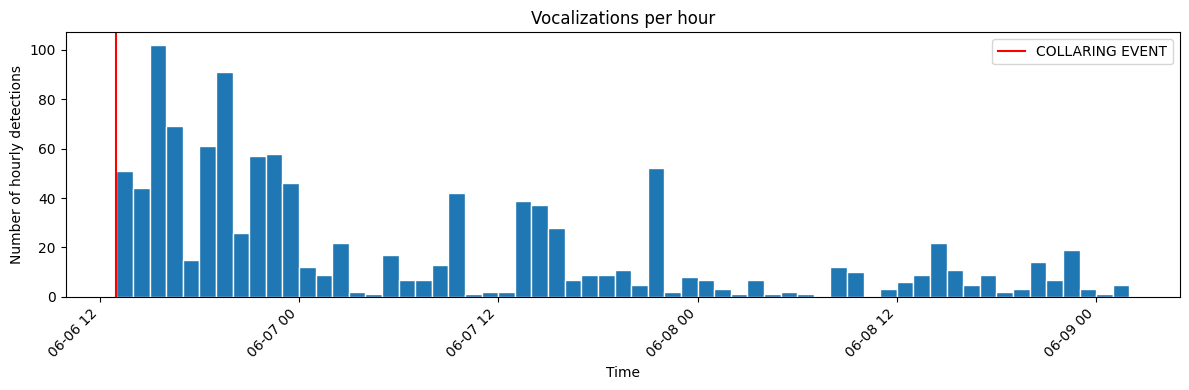

In [30]:
#plot of time series with hourly bins
# includes all detections (not just high quality ones)

all_timestamps = []
for ann_path in ann_files:
    df = pd.read_csv(ann_path, sep='\t')
    parts = ann_path.stem.split('_')
    rec_start = datetime.strptime(parts[1] + parts[2], '%Y%m%d%H%M%S')
    all_timestamps += [rec_start + timedelta(seconds=t) for t in df['Begin Time (s)']]

all_detections = pd.DataFrame({'abs_begin': all_timestamps})

hourly = all_detections['abs_begin'].dt.floor('h').value_counts().sort_index()
fig, ax = plt.subplots(figsize=(12, 4))
ax.axvline(pd.Timestamp('2025-06-06 13:00'), color='red', label = 'COLLARING EVENT')
ax.legend()
ax.bar(hourly.index, hourly.values, width=pd.Timedelta(hours=1), align='edge',edgecolor='white')
ax.set_xlabel('Time')
ax.set_ylabel('Number of hourly detections')
ax.set_title('Vocalizations per hour')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()